In [2]:
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
# import visualkeras as vk

from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Conv2D,
    Activation,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from sklearn.metrics import confusion_matrix

In [ ]:
# !pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.2 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np

data = np.load("/content/drive/MyDrive/character recognition/dataset.npz")

In [5]:
train_data = data["train_data"]
test_data = data["test_data"]

train_labels = data["train_labels"]
test_labels = data["test_labels"]

In [6]:
model = Sequential()

model.add(Conv2D(32, (5, 5), input_shape=(28, 28, 1), activation="relu"))
model.add(BatchNormalization())

model.add(Conv2D(32, (5, 5), activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(2, 2))
model.add(Dropout(0.25))

model.add(BatchNormalization())
model.add(Flatten())

model.add(Dense(256, activation="relu"))
model.add(Dense(36, activation="softmax"))

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 20, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 855,556 (3.26 MB)

 Trainable params: 855,364 (3.26 MB)

 Non-trainable params: 192 (768.00 B)

In [7]:
best_loss_checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/character recognition/models/best_loss_model.weights.h5",
    monitor="loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min"
)

best_val_loss_checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/character recognition/models/best_val_loss_model.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min"
)

In [8]:
history = model.fit(
    train_data,
    train_labels,
    validation_data=(test_data, test_labels),
    epochs=10,
    batch_size=200,
    callbacks=[best_loss_checkpoint, best_val_loss_checkpoint]
)

Epoch 1/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.9479 - loss: 0.1816 - val_accuracy: 0.9703 - val_loss: 0.1031
Epoch 2/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9744 - loss: 0.0853 - val_accuracy: 0.9738 - val_loss: 0.0915
Epoch 3/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9797 - loss: 0.0647 - val_accuracy: 0.9775 - val_loss: 0.0798
Epoch 4/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9832 - loss: 0.0523 - val_accuracy: 0.9798 - val_loss: 0.0690
Epoch 5/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9859 - loss: 0.0434 - val_accuracy: 0.9832 - val_loss: 0.0597
Epoch 6/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9876 - loss: 0.0371 - val_accuracy: 0.9845 - val_loss: 0.0572
Epoch 7/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9890 - loss: 0.0328 - val_accuracy: 0.9850 - val_loss: 0.0592
Epoch 8/10
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9900 - loss:

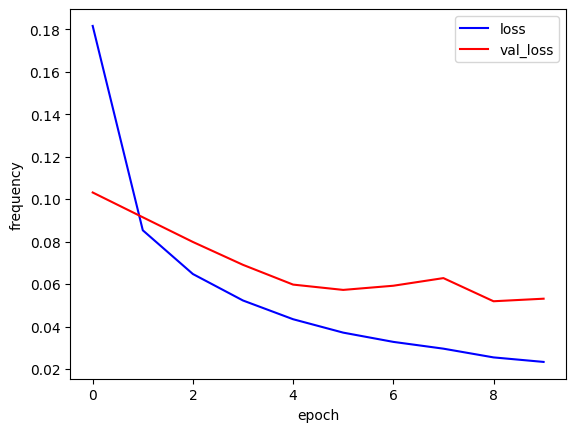

In [9]:
plt.plot(history.history["loss"], 'b', label="loss")
plt.plot(history.history["val_loss"], 'r', label="val_loss")
plt.xlabel("epoch")
plt.ylabel("frequency")
plt.legend()
plt.show()

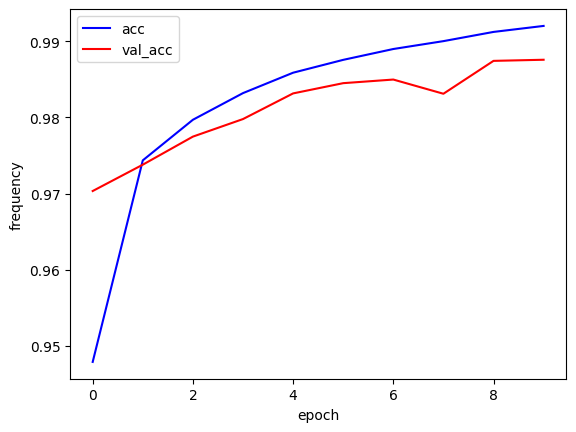

In [10]:
plt.plot(history.history["accuracy"], 'b', label="acc")
plt.plot(history.history["val_accuracy"], 'r', label="val_acc")
plt.xlabel("epoch")
plt.ylabel("frequency")
plt.legend()
plt.show()

In [11]:
model.load_weights("/content/drive/MyDrive/character recognition/models/best_val_loss_model.weights.h5")

In [12]:
loss, acc = model.evaluate(test_data, test_labels)
print(loss, acc)

2766/2766 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9874 - loss: 0.0519
0.051902808248996735 0.9874222874641418


In [13]:
predictions = model.predict(test_data)

2766/2766 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [14]:
confusion = confusion_matrix(
    np.argmax(test_labels, axis=1),
    np.argmax(predictions, axis=1)
)
print(confusion)

[[2765    0    0 ...    0    0    0]
 [   2 1682    0 ...    0    4    0]
 [   0    0 4665 ...    0    0    0]
 ...
 [   0    0    0 ... 1457    0    1]
 [   0    6    0 ...    0 1316    8]
 [   0    0    1 ...    4    0 1355]]


<Axes: xlabel='predicted', ylabel='actual'>

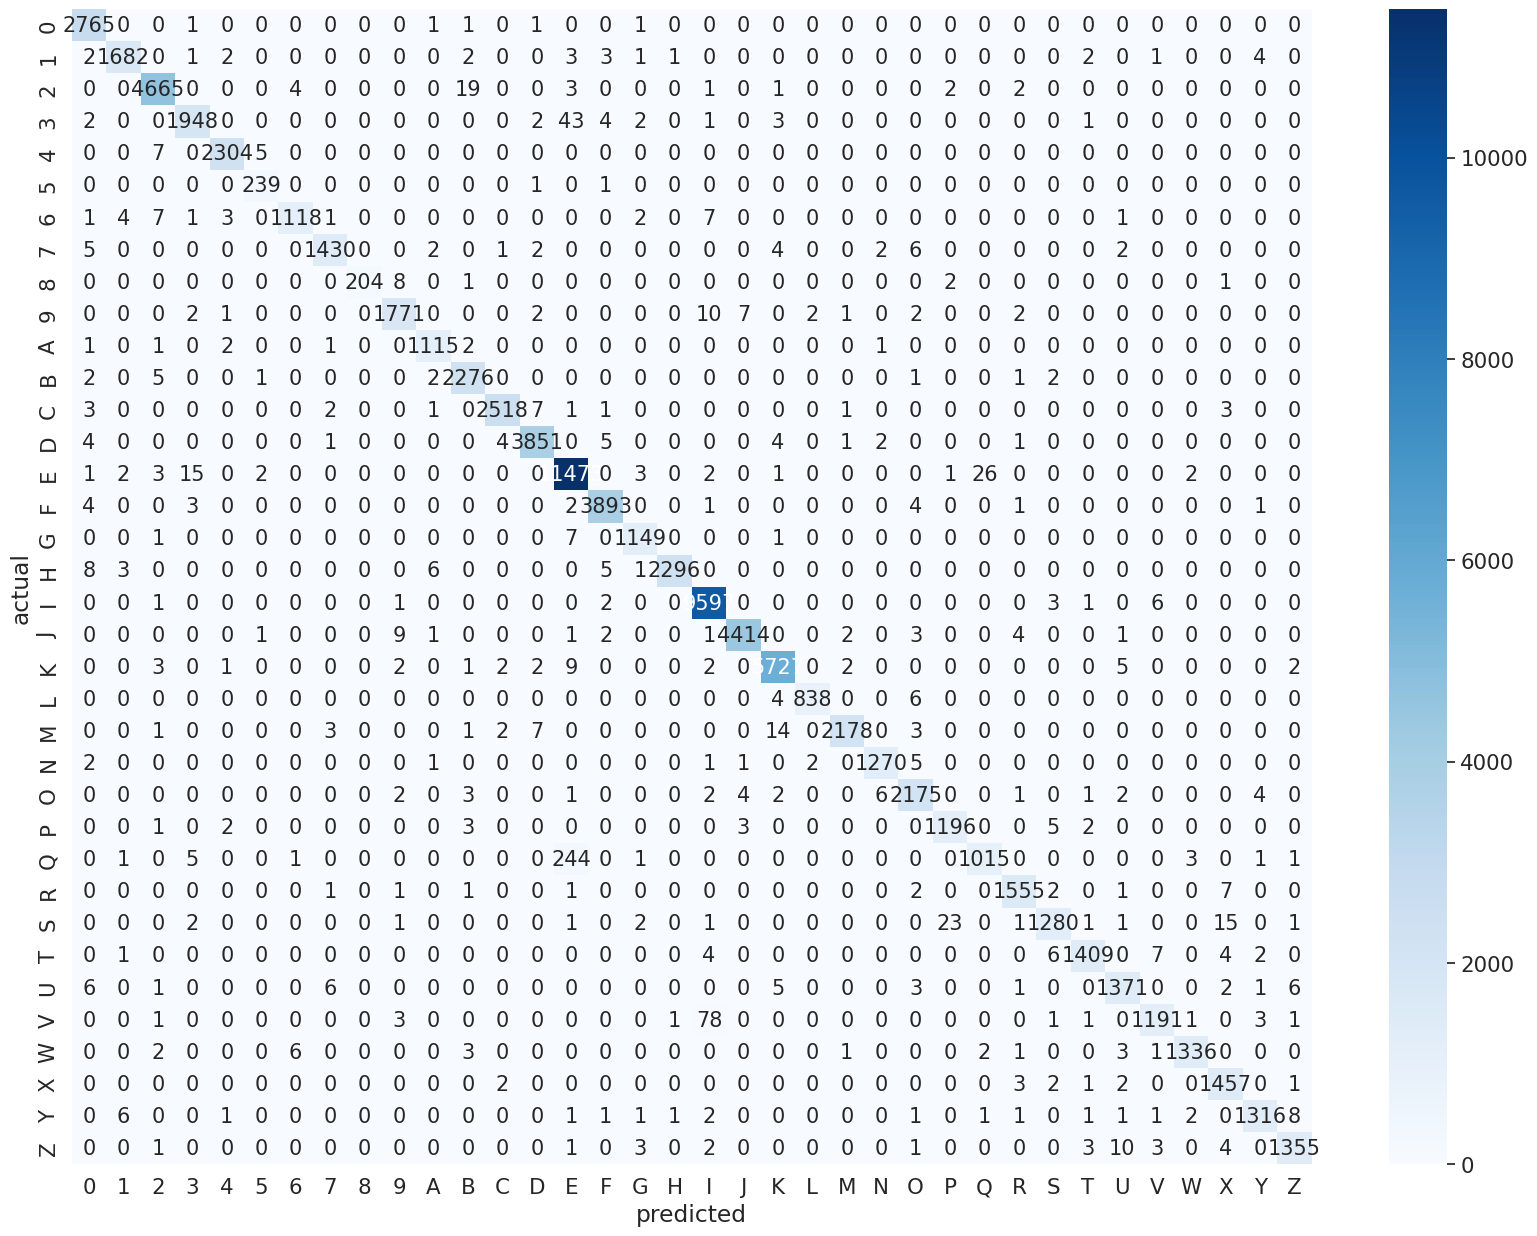

In [15]:
labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

df_cm = pd.DataFrame(confusion, columns=np.unique(labels), index = np.unique(labels))
df_cm.index.name = 'actual'
df_cm.columns.name = 'predicted'
plt.figure(figsize = (20,15))
sn.set(font_scale=1.4)
sn.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 15}, fmt="d")

In [16]:
import cv2 as cv
import os

In [23]:
def predict_sample_images(image_folder_path):
  files = os.listdir(image_folder_path)
  for file in files:
    img_path = os.path.join(image_folder_path, file)
    img = cv.imread(img_path)

    # Convert to grayscale
    gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    # Resize to 28x28
    resized_img = cv.resize(gray_img, (28, 28))
    # Reshape for model input (add batch and channel dimensions)
    input_img = resized_img.reshape(1, 28, 28, 1)
    # Normalize (assuming the model was trained on normalized data)
    input_img = input_img / 255.0

    # Predict
    prediction = model.predict(input_img, verbose=0)
    predicted_class_index = np.argmax(prediction)
    predicted_character = labels[predicted_class_index]

    print(f"Image: {file}, Predicted Character: {predicted_character}")

    # Display the image with its prediction
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)) # Display original color image
    plt.title(f"Predicted: {predicted_character}")
    plt.axis('off') # Hide axes
    plt.show()


Image: image_4.png, Predicted Character: 2


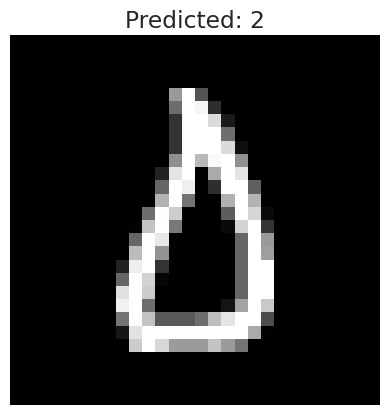

Image: image_2.png, Predicted Character: 8


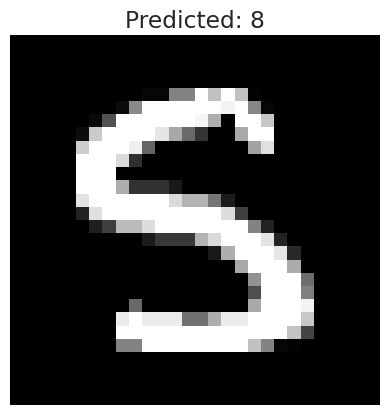

Image: image_3.png, Predicted Character: M


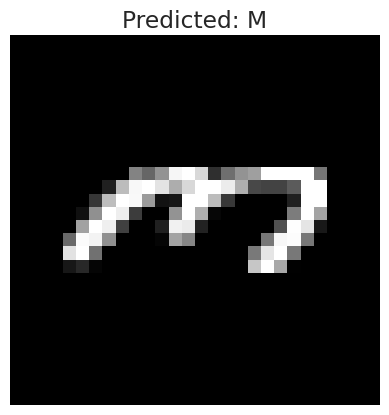

Image: image_1.png, Predicted Character: R


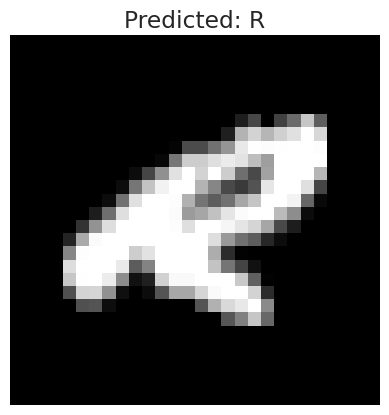

Image: image_0.png, Predicted Character: 8


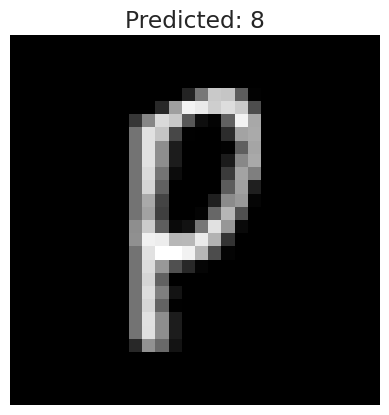

Image: image_9.png, Predicted Character: 2


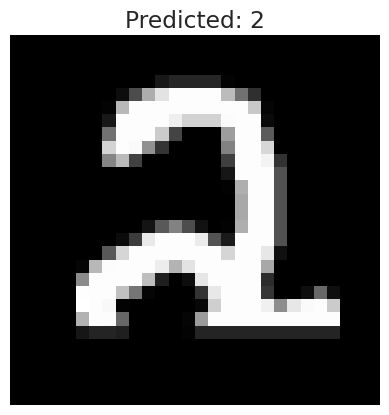

Image: image_7.png, Predicted Character: 1


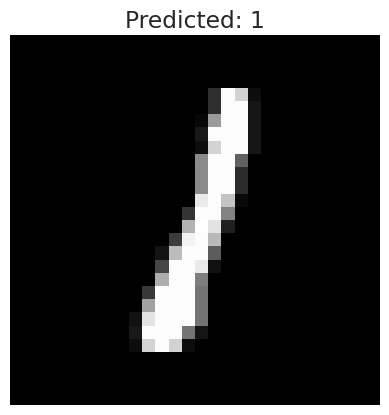

Image: image_6.png, Predicted Character: 7


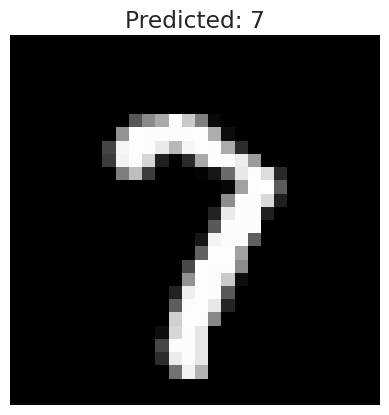

Image: image_5.png, Predicted Character: 8


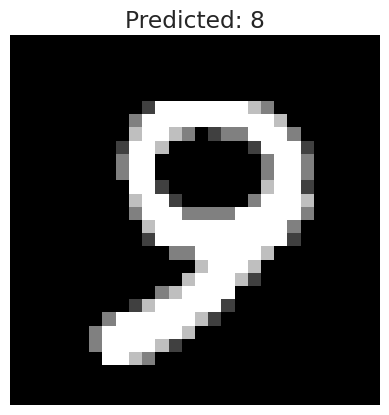

Image: image_8.png, Predicted Character: 7


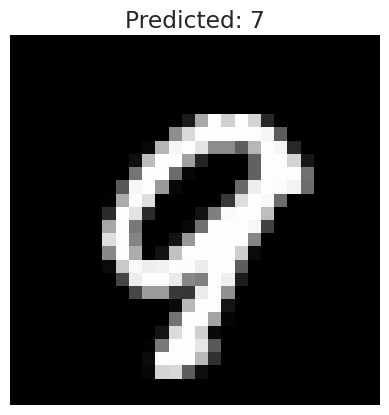

In [24]:
sample_images_path = "/content/drive/MyDrive/character recognition/sample images"
predict_sample_images(sample_images_path)